In [ ]:
# ============================================================================
# Cell 1: Import Libraries with GPU Detection
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from google.colab import files
import time
import warnings
warnings.filterwarnings('ignore')

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✓ GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("✓ Using CPU (Go to Runtime → Change runtime type → T4 GPU for faster training)")

print(f"✓ PyTorch version: {torch.__version__}")

torch.manual_seed(42)
np.random.seed(42)

✓ GPU Available: Tesla T4
✓ GPU Memory: 15.6 GB
✓ PyTorch version: 2.10.0+cu128


In [ ]:
# ============================================================================
# Cell 2: Upload DNS Data
# ============================================================================

print("Upload your .mat file")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
data = sio.loadmat(file_name)

print(f"✓ Loaded: {file_name}")
print(f"Samples: {data['C_eff_data'].shape[2]}")

Upload your .mat file


Saving C_eff_dataset_500.mat to C_eff_dataset_500.mat
✓ Loaded: C_eff_dataset_500.mat
Samples: 500


In [ ]:
# ============================================================================
# Cell 3: Rotation Functions - GPU Optimized (CORRECTED)
# ============================================================================

def rotation_matrix_torch(theta, batch_size=None):
    """
    Eq. 9 - Rotation matrix in Mandel notation
    For 3x3 matrix (2D plane strain)
    """
    if batch_size is None:
        batch_size = theta.shape[0]

    device = theta.device
    dtype = theta.dtype

    c = torch.cos(theta)
    s = torch.sin(theta)
    sqrt2 = np.sqrt(2)

    # Create rotation matrix for each sample in batch
    R = torch.zeros(batch_size, 3, 3, device=device, dtype=dtype)

    # Fill according to Eq. 9
    R[:, 0, 0] = c**2
    R[:, 0, 1] = s**2
    R[:, 0, 2] = sqrt2 * c * s

    R[:, 1, 0] = s**2
    R[:, 1, 1] = c**2
    R[:, 1, 2] = -sqrt2 * c * s

    R[:, 2, 0] = -sqrt2 * c * s
    R[:, 2, 1] = sqrt2 * c * s
    R[:, 2, 2] = c**2 - s**2  # cos²θ - sin²θ = cos(2θ)

    return R


def mat3_to_vec6(D_mat):
    """
    Convert 3x3 Mandel compliance matrix to 6-component vector
    [D11, D12, D13, D22, D23, D33]
    """
    batch_size = D_mat.shape[0]
    device = D_mat.device
    dtype = D_mat.dtype

    D_vec = torch.zeros(batch_size, 6, device=device, dtype=dtype)
    D_vec[:, 0] = D_mat[:, 0, 0]  # D11
    D_vec[:, 1] = D_mat[:, 0, 1]  # D12
    D_vec[:, 2] = D_mat[:, 0, 2]  # D13
    D_vec[:, 3] = D_mat[:, 1, 1]  # D22
    D_vec[:, 4] = D_mat[:, 1, 2]  # D23
    D_vec[:, 5] = D_mat[:, 2, 2]  # D33
    return D_vec


def vec6_to_mat3(D_vec):
    """
    Convert 6-component vector to 3x3 Mandel compliance matrix
    """
    batch_size = D_vec.shape[0]
    device = D_vec.device
    dtype = D_vec.dtype

    D_mat = torch.zeros(batch_size, 3, 3, device=device, dtype=dtype)
    D_mat[:, 0, 0] = D_vec[:, 0]  # D11
    D_mat[:, 0, 1] = D_vec[:, 1]  # D12
    D_mat[:, 0, 2] = D_vec[:, 2]  # D13
    D_mat[:, 1, 0] = D_vec[:, 1]  # D12 (symmetric)
    D_mat[:, 1, 1] = D_vec[:, 3]  # D22
    D_mat[:, 1, 2] = D_vec[:, 4]  # D23
    D_mat[:, 2, 0] = D_vec[:, 2]  # D13 (symmetric)
    D_mat[:, 2, 1] = D_vec[:, 4]  # D23 (symmetric)
    D_mat[:, 2, 2] = D_vec[:, 5]  # D33
    return D_mat


def rotate_compliance_batch(D_vec, theta):
    """
    Rotate batch of compliance vectors using Eq. 11
    D_bar = R(-θ) * D^r * R(θ)
    """
    batch_size = D_vec.shape[0]

    # Convert to matrix form
    D_mat = vec6_to_mat3(D_vec)

    # Get rotation matrices
    R = rotation_matrix_torch(theta, batch_size)
    R_minus = rotation_matrix_torch(-theta, batch_size)

    # Apply rotation: R(-θ) * D * R(θ)
    # batch matrix multiplication
    D_rotated = torch.bmm(R_minus, torch.bmm(D_mat, R))

    # Convert back to vector form
    return mat3_to_vec6(D_rotated)


print("✓ GPU-optimized rotation functions defined (CORRECTED)")

✓ GPU-optimized rotation functions defined (CORRECTED)


In [ ]:
# ============================================================================
# Cell 4: Building Block Module (CORRECTED)
# ============================================================================

class BuildingBlock(nn.Module):
    """
    Implements the two-layer building block described in Section 2.1
    """
    def __init__(self):
        super().__init__()
        # f1 will be set externally (volume fraction of material 1)
        # theta will be set externally (rotation angle)

    def forward(self, D1, D2, f1, theta):
        """
        Forward pass implementing Eq. 8 (homogenization) and Eq. 11 (rotation)

        Args:
            D1: Compliance vector of material 1 [batch, 6]
            D2: Compliance vector of material 2 [batch, 6]
            f1: Volume fraction of material 1 [batch] or scalar
            theta: Rotation angle [batch] or scalar
        """
        batch_size = D1.shape[0]
        device = D1.device
        dtype = D1.dtype

        # Ensure f1 and theta are tensors with batch dimension
        if not isinstance(f1, torch.Tensor):
            f1 = torch.tensor(f1, device=device, dtype=dtype)
        if f1.dim() == 0:
            f1 = f1.expand(batch_size)

        if not isinstance(theta, torch.Tensor):
            theta = torch.tensor(theta, device=device, dtype=dtype)
        if theta.dim() == 0:
            theta = theta.expand(batch_size)

        f2 = 1 - f1

        # Unpack compliance components
        D11_1, D12_1, D13_1, D22_1, D23_1, D33_1 = (
            D1[:, 0], D1[:, 1], D1[:, 2], D1[:, 3], D1[:, 4], D1[:, 5]
        )
        D11_2, D12_2, D13_2, D22_2, D23_2, D33_2 = (
            D2[:, 0], D2[:, 1], D2[:, 2], D2[:, 3], D2[:, 4], D2[:, 5]
        )

        # Eq. 8 - Homogenization of two-layer structure
        Gamma = f1 * D11_2 + f2 * D11_1 + 1e-10

        D11_prime = (D11_1 * D11_2) / Gamma
        D12_prime = (f1 * D12_1 * D11_2 + f2 * D12_2 * D11_1) / Gamma
        D13_prime = (f1 * D13_1 * D11_2 + f2 * D13_2 * D11_1) / Gamma

        D22_prime = (f1 * D22_1 + f2 * D22_2 -
                     (f1 * f2 * (D12_1 - D12_2)**2) / Gamma)
        D23_prime = (f1 * D23_1 + f2 * D23_2 -
                     (f1 * f2 * (D13_1 - D13_2) * (D12_1 - D12_2)) / Gamma)
        D33_prime = (f1 * D33_1 + f2 * D33_2 -
                     (f1 * f2 * (D13_1 - D13_2)**2) / Gamma)

        # Stack into vector
        D_prime = torch.stack([
            D11_prime, D12_prime, D13_prime,
            D22_prime, D23_prime, D33_prime
        ], dim=1)

        # Eq. 11 - Rotation
        D_rotated = rotate_compliance_batch(D_prime, theta)

        return D_rotated


print("✓ BuildingBlock defined (CORRECTED)")

✓ BuildingBlock defined (CORRECTED)


In [ ]:
# ============================================================================
# Cell 5: Material Network (CORRECTED)
# ============================================================================

class MaterialNetwork(nn.Module):
    """
    Deep Material Network as described in Section 2.2
    Binary tree structure with depth N
    """
    def __init__(self, depth, D1_init, D2_init):
        """
        Args:
            depth: Depth of the network (N)
            D1_init: Initial compliance vector for phase 1 [6]
            D2_init: Initial compliance vector for phase 2 [6]
        """
        super().__init__()
        self.depth = depth
        self.n_bottom = 2**depth  # Number of nodes at bottom layer

        # Learnable activation parameters at bottom layer (Eq. 21)
        self.z = nn.Parameter(torch.rand(self.n_bottom) * 0.5 + 0.3)  # Initialize between 0.3 and 0.8

        # Learnable rotation angles for each node
        # theta_i^k for layer i, node k
        self.thetas = nn.ParameterList()
        for i in range(depth + 1):  # layers 0 to N
            n_nodes = 2**i
            self.thetas.append(
                nn.Parameter(torch.rand(n_nodes) * np.pi - np.pi/2)  # Initialize between -π/2 and π/2
            )

        # Store reference compliance for both phases
        self.register_buffer('D1_ref', D1_init.unsqueeze(0))  # [1, 6]
        self.register_buffer('D2_ref', D2_init.unsqueeze(0))  # [1, 6]

        # Create building blocks
        self.building_block = BuildingBlock()

    def get_bottom_weights(self, batch_size):
        """
        Get weights at bottom layer using ReLU activation (Eq. 21)
        w_N^j = ReLU(z_N^j)
        """
        return torch.relu(self.z).unsqueeze(0).expand(batch_size, -1)  # [batch, n_bottom]

    def compute_node_compliance(self, D1_batch, D2_batch, node_weights, layer, batch_size):
        """
        Compute compliance for all nodes at a given layer using hierarchical homogenization
        """
        n_nodes = 2**layer
        node_comp = []

        for node in range(n_nodes):
            if layer == self.depth:
                # Bottom layer: each node gets mixture of phases
                # The node's compliance is a weighted mixture based on its phase assignment
                # For simplicity, we alternate phase assignments initially
                # This will be learned through training
                if node % 2 == 0:
                    node_comp.append(D1_batch * node_weights[:, node:node+1])
                else:
                    node_comp.append(D2_batch * node_weights[:, node:node+1])
            else:
                # Higher layers: homogenize child nodes
                child1_idx = 2 * node
                child2_idx = 2 * node + 1

                D_child1 = node_comp[child1_idx]
                D_child2 = node_comp[child2_idx]

                # Get volume fractions for children
                w_child1 = node_weights[:, 2*node*2**(self.depth-layer):(2*node+1)*2**(self.depth-layer)].sum(dim=1)
                w_child2 = node_weights[:, (2*node+1)*2**(self.depth-layer):(2*node+2)*2**(self.depth-layer)].sum(dim=1)
                w_total = w_child1 + w_child2 + 1e-10
                f1 = w_child1 / w_total

                # Get rotation angle for this node
                theta = self.thetas[layer][node].expand(batch_size)

                # Homogenize and rotate
                D_parent = self.building_block(D_child1, D_child2, f1, theta)
                node_comp.append(D_parent)

        return node_comp

    def forward(self, D1, D2):
        """
        Forward pass through the material network
        Args:
            D1: Compliance vectors for phase 1 [batch, 6]
            D2: Compliance vectors for phase 2 [batch, 6]
        Returns:
            Homogenized compliance at output layer [batch, 6]
        """
        batch_size = D1.shape[0]

        # Get bottom layer weights (Eq. 21)
        w_bottom = self.get_bottom_weights(batch_size)  # [batch, n_bottom]

        # Compute compliances for all layers
        all_compliances = []

        # For simplicity, we'll implement a recursive-like approach
        # Start from bottom and work up

        # Bottom layer nodes
        n_bottom = self.n_bottom
        bottom_compliances = []

        for j in range(n_bottom):
            # Each bottom node gets a weighted mixture of both phases
            # The weight determines which phase dominates
            if j % 2 == 0:
                bottom_compliances.append(D1.clone() * w_bottom[:, j:j+1])
            else:
                bottom_compliances.append(D2.clone() * w_bottom[:, j:j+1])

        # Work upward through layers
        current_compliances = bottom_compliances

        for layer in range(self.depth - 1, -1, -1):
            n_nodes = 2**layer
            next_compliances = []

            for node in range(n_nodes):
                child1 = 2 * node
                child2 = 2 * node + 1

                D_child1 = current_compliances[child1]
                D_child2 = current_compliances[child2]

                # Compute volume fractions
                descendant_start = node * 2**(self.depth - layer)
                descendant_end = (node + 1) * 2**(self.depth - layer)

                w_subtree = w_bottom[:, descendant_start:descendant_end]
                w_total = w_subtree.sum(dim=1) + 1e-10

                # Split into left and right children
                mid = (descendant_start + descendant_end) // 2
                w_left = w_bottom[:, descendant_start:mid].sum(dim=1)
                w_right = w_bottom[:, mid:descendant_end].sum(dim=1)

                f1 = w_left / w_total

                # Get rotation angle
                theta = self.thetas[layer][node].expand(batch_size)

                # Homogenize
                D_parent = self.building_block(D_child1, D_child2, f1, theta)
                next_compliances.append(D_parent)

            current_compliances = next_compliances

        # Output layer (layer 0) has 1 node
        return current_compliances[0]

    def regularization(self, lambda_reg=1e-6):
        """
        Regularization term from Eq. 34
        L(z) = (sum_j ReLU(z_N^j) - ξ)²
        where ξ = 2^(N-1) from Eq. 48
        """
        z_act = torch.relu(self.z)
        xi = 2**(self.depth - 1)
        return 0.5 * lambda_reg * (torch.sum(z_act) - xi)**2


print("✓ MaterialNetwork defined (CORRECTED)")

✓ MaterialNetwork defined (CORRECTED)


In [ ]:
# ============================================================================
# Cell 6: Prepare Data (CORRECTED)
# ============================================================================

def prepare_data(data):
    """
    Prepare training data from DNS results
    Since your data is already 3x3 in Mandel notation:
    [C11, C12, C13; C12, C22, C23; C13, C23, C33]

    Convert to compliance vectors [D11, D12, D13, D22, D23, D33]
    """
    n = data['C_eff_data'].shape[2]
    X1, X2, Y = [], [], []

    print(f"Processing {n} samples...")

    for i in range(n):
        # Phase 1 stiffness (already 3x3) -> compliance
        C_p1 = data['C_p1'][:, :, i]
        D1_mat = np.linalg.inv(C_p1)
        # Convert to Mandel 6-vector
        D1 = np.array([
            D1_mat[0, 0], D1_mat[0, 1], D1_mat[0, 2],
            D1_mat[1, 1], D1_mat[1, 2], D1_mat[2, 2]
        ], dtype=np.float32)

        # Phase 2 stiffness (already 3x3) -> compliance
        C_p2 = data['C_p2'][:, :, i]
        D2_mat = np.linalg.inv(C_p2)
        D2 = np.array([
            D2_mat[0, 0], D2_mat[0, 1], D2_mat[0, 2],
            D2_mat[1, 1], D2_mat[1, 2], D2_mat[2, 2]
        ], dtype=np.float32)

        # Target: effective stiffness (already 3x3) -> compliance
        C_eff = data['C_eff_data'][:, :, i]
        D_target_mat = np.linalg.inv(C_eff)
        D_target = np.array([
            D_target_mat[0, 0], D_target_mat[0, 1], D_target_mat[0, 2],
            D_target_mat[1, 1], D_target_mat[1, 2], D_target_mat[2, 2]
        ], dtype=np.float32)

        X1.append(D1)
        X2.append(D2)
        Y.append(D_target)

    return np.array(X1), np.array(X2), np.array(Y)

# Prepare data
X1, X2, Y = prepare_data(data)
print(f"\n✓ Prepared {len(X1)} samples")

# Split data
n = len(X1)
indices = np.random.permutation(n)
train_idx = indices[:int(0.6 * n)]
val_idx = indices[int(0.6 * n):int(0.8 * n)]
test_idx = indices[int(0.8 * n):]

# Convert to tensors
X1_train = torch.tensor(X1[train_idx], device=device, dtype=torch.float32)
X2_train = torch.tensor(X2[train_idx], device=device, dtype=torch.float32)
Y_train = torch.tensor(Y[train_idx], device=device, dtype=torch.float32)

X1_val = torch.tensor(X1[val_idx], device=device, dtype=torch.float32)
X2_val = torch.tensor(X2[val_idx], device=device, dtype=torch.float32)
Y_val = torch.tensor(Y[val_idx], device=device, dtype=torch.float32)

X1_test = torch.tensor(X1[test_idx], device=device, dtype=torch.float32)
X2_test = torch.tensor(X2[test_idx], device=device, dtype=torch.float32)
Y_test = torch.tensor(Y[test_idx], device=device, dtype=torch.float32)

# Create data loaders
batch_size = 64
train_dataset = TensorDataset(X1_train, X2_train, Y_train)
val_dataset = TensorDataset(X1_val, X2_val, Y_val)
test_dataset = TensorDataset(X1_test, X2_test, Y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Verify data quality
print("\nVerifying data quality...")
print(f"Phase 1 D11 range: [{X1[:, 0].min():.4f}, {X1[:, 0].max():.4f}]")
print(f"Phase 2 D11 range: [{X2[:, 0].min():.4f}, {X2[:, 0].max():.4f}]")
print(f"Target D11 range: [{Y[:, 0].min():.4f}, {Y[:, 0].max():.4f}]")

Processing 500 samples...

✓ Prepared 500 samples
Train: 300, Val: 100, Test: 100

Verifying data quality...
Phase 1 D11 range: [0.0743, 14.5397]
Phase 2 D11 range: [0.0002, 3471.8699]
Target D11 range: [0.0555, 21.2488]


In [ ]:
# ============================================================================
# Cell 7: Trainer with SGD Optimizer (As described in paper Section 3.2)
# ============================================================================

class Trainer:
    def __init__(self, model, lr=0.01, lambda_reg=1e-6, momentum=0.0):
        """
        Trainer with SGD optimizer as described in Section 3.2

        Args:
            model: MaterialNetwork model
            lr: Learning rate η (Eq. 45-46)
            lambda_reg: Regularization strength λ (Eq. 33)
            momentum: Momentum for SGD (0 = vanilla SGD)
        """
        self.model = model
        self.lambda_reg = lambda_reg

        # SGD optimizer as used in the paper
        # The paper mentions using "Bold driver" algorithm for dynamic learning rate
        # We'll implement this manually
        self.optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum  # Paper doesn't explicitly mention momentum, but it can help
        )

        # Bold driver learning rate adaptation (Section 3.2)
        self.bold_driver_factor_up = 1.05     # Increase LR by 5% if loss decreases
        self.bold_driver_factor_down = 0.5    # Halve LR if loss increases
        self.best_val_loss = float('inf')

        self.train_losses = []  # Store training loss history
        self.val_losses = []    # Store validation loss history
        self.learning_rates = []  # Track learning rate changes

    def compute_loss(self, pred, target):
        """
        Eq. 30: Normalized MSE cost function
        C₀ = (1/2) · ||D^dns - D^mn||² / ||D^dns||²

        The normalization by ||D^dns||² removes scaling effects
        Loss is dimensionless, making it easier to train
        """
        diff = pred - target  # Prediction error

        # Frobenius norm squared of error: Σ(diff_ij)²
        frob_error = torch.sum(diff**2, dim=1)  # [batch_size]

        # Frobenius norm squared of target (for normalization)
        frob_target = torch.sum(target**2, dim=1) + 1e-10  # [batch_size]

        # Normalized loss per sample
        loss_per_sample = frob_error / frob_target

        # Scale by 0.5 as in Eq. 30
        return 0.5 * loss_per_sample.mean()  # Average over batch

    def total_loss(self, pred, target):
        """
        Eq. 33: Total cost function
        C = C₀ + λ·L(z)

        C₀: Data term (fitting error)
        L(z): Regularization term (constrains weight magnitudes)
        λ: Hyperparameter balancing the two terms
        """
        data_loss = self.compute_loss(pred, target)
        reg_loss = self.model.regularization(self.lambda_reg)
        return data_loss + reg_loss

    def train_epoch(self, loader):
        """One epoch of training over the dataset using SGD"""
        self.model.train()  # Set model to training mode
        total_loss = 0

        for X1, X2, Y in loader:  # Iterate over mini-batches
            self.optimizer.zero_grad()  # Clear previous gradients

            pred = self.model(X1, X2)   # Forward pass
            loss = self.total_loss(pred, Y)  # Compute loss

            loss.backward()  # Backpropagation (compute gradients)

            # Gradient clipping: prevents exploding gradients
            # (Paper doesn't explicitly mention this, but it's good practice)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

            self.optimizer.step()  # Update parameters: θ' = θ - η·∇C (Eq. 45-46)

            total_loss += loss.item()  # Accumulate loss

        return total_loss / len(loader)  # Average loss per batch

    def validate(self, loader):
        """Evaluate model on validation set"""
        self.model.eval()  # Set model to evaluation mode
        total_loss = 0

        with torch.no_grad():  # Disable gradient computation
            for X1, X2, Y in loader:
                pred = self.model(X1, X2)
                # Use data loss only (no regularization) for validation
                loss = self.compute_loss(pred, Y)
                total_loss += loss.item()

        return total_loss / len(loader)

    def bold_driver_update(self, current_val_loss):
        """
        Bold driver algorithm for dynamic learning rate (Section 3.2)

        If validation loss decreases: increase learning rate slightly
        If validation loss increases: decrease learning rate significantly
        """
        if current_val_loss < self.best_val_loss:
            # Loss improved - increase learning rate
            for param_group in self.optimizer.param_groups:
                param_group['lr'] *= self.bold_driver_factor_up
            self.best_val_loss = current_val_loss
        else:
            # Loss worsened - decrease learning rate
            for param_group in self.optimizer.param_groups:
                param_group['lr'] *= self.bold_driver_factor_down
            # Note: We don't update best_val_loss here

    def train(self, train_loader, val_loader, epochs=500,
              bold_driver=True, bold_driver_start_epoch=10):
        """
        Full training loop with SGD and optional Bold driver

        Args:
            train_loader: Training data loader
            val_loader: Validation data loader
            epochs: Number of training epochs
            bold_driver: Whether to use Bold driver learning rate adaptation
            bold_driver_start_epoch: Start Bold driver after this many epochs
        """
        print(f"\n{'='*60}")
        print(f"TRAINING ON {device}")
        print(f"{'='*60}")
        print(f"Optimizer: SGD")
        print(f"Initial LR: {self.optimizer.param_groups[0]['lr']}")
        print(f"Momentum: {self.optimizer.param_groups[0].get('momentum', 0)}")
        print(f"Bold driver: {'Enabled' if bold_driver else 'Disabled'}")
        print(f"λ_reg: {self.lambda_reg}")
        print(f"{'='*60}\n")

        start_time = time.time()

        for epoch in range(epochs):
            train_loss = self.train_epoch(train_loader)
            val_loss = self.validate(val_loader)

            self.train_losses.append(train_loss)  # Record training loss
            self.val_losses.append(val_loss)      # Record validation loss
            self.learning_rates.append(
                self.optimizer.param_groups[0]['lr']
            )

            # Bold driver learning rate adaptation (Eq. 45-46 context)
            if bold_driver and epoch >= bold_driver_start_epoch:
                self.bold_driver_update(val_loss)

            # Print progress every 50 epochs
            if (epoch + 1) % 50 == 0 or epoch == 0:
                elapsed = time.time() - start_time
                current_lr = self.optimizer.param_groups[0]['lr']
                active_nodes = (torch.relu(self.model.z) > 1e-6).sum().item()
                print(f"Epoch {epoch+1:3d}: LR={current_lr:.6f}, "
                      f"Train={train_loss:.6f}, Val={val_loss:.6f}, "
                      f"Active={active_nodes}, Time={elapsed:.0f}s")

        total_time = time.time() - start_time
        print(f"\n✓ Training complete in {total_time/60:.2f} minutes")
        print(f"Final learning rate: {self.optimizer.param_groups[0]['lr']:.6f}")
        print(f"Final active bottom nodes: {(torch.relu(self.model.z) > 1e-6).sum().item()}")

    def plot(self):
        """Plot training history with learning rate"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Loss plot
        ax1.plot(self.train_losses, label='Train Loss')
        ax1.plot(self.val_losses, label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training History (SGD)')
        ax1.legend()
        ax1.set_yscale('log')
        ax1.grid(True, alpha=0.3)

        # Learning rate plot
        ax2.plot(self.learning_rates)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Learning Rate')
        ax2.set_title('Learning Rate Schedule (Bold Driver)')
        ax2.grid(True, alpha=0.3)
        if len(set(self.learning_rates)) > 1:
            ax2.set_yscale('log')

        plt.tight_layout()
        plt.show()


# SGD-specific configuration
print("✓ SGD Trainer with Bold Driver defined")
print("\nRecommended hyperparameters for SGD (from paper):")
print("  - Learning rate: 0.01 - 0.1 (start higher than Adam)")
print("  - Bold driver factors: up=1.05, down=0.5")
print("  - λ_reg: 1e-6 (same as before)")
print("  - May need more epochs than Adam for convergence")

✓ SGD Trainer with Bold Driver defined

Recommended hyperparameters for SGD (from paper):
  - Learning rate: 0.01 - 0.1 (start higher than Adam)
  - Bold driver factors: up=1.05, down=0.5
  - λ_reg: 1e-6 (same as before)
  - May need more epochs than Adam for convergence


GPU Memory before training: 0.00 GB
Model depth: 5
Bottom nodes: 32
Trainable parameters: 95

TRAINING ON cuda
Optimizer: SGD
Initial LR: 0.01
Momentum: 0.0
Bold driver: Enabled
λ_reg: 1e-06

Epoch   1: LR=0.010000, Train=20.894115, Val=26.375407, Active=32, Time=3s
Epoch  50: LR=0.070400, Train=0.250901, Val=0.216794, Active=28, Time=88s
Epoch 100: LR=0.000000, Train=0.238211, Val=0.209973, Active=26, Time=176s
Epoch 150: LR=0.000000, Train=0.236691, Val=0.209973, Active=26, Time=262s
Epoch 200: LR=0.000000, Train=0.235136, Val=0.209973, Active=26, Time=349s
Epoch 250: LR=0.000000, Train=0.237345, Val=0.209973, Active=26, Time=435s
Epoch 300: LR=0.000000, Train=0.239715, Val=0.209973, Active=26, Time=522s
Epoch 350: LR=0.000000, Train=0.233452, Val=0.209973, Active=26, Time=609s
Epoch 400: LR=0.000000, Train=0.235697, Val=0.209973, Active=26, Time=696s
Epoch 450: LR=0.000000, Train=0.235743, Val=0.209973, Active=26, Time=783s
Epoch 500: LR=0.000000, Train=0.234653, Val=0.209973, Activ

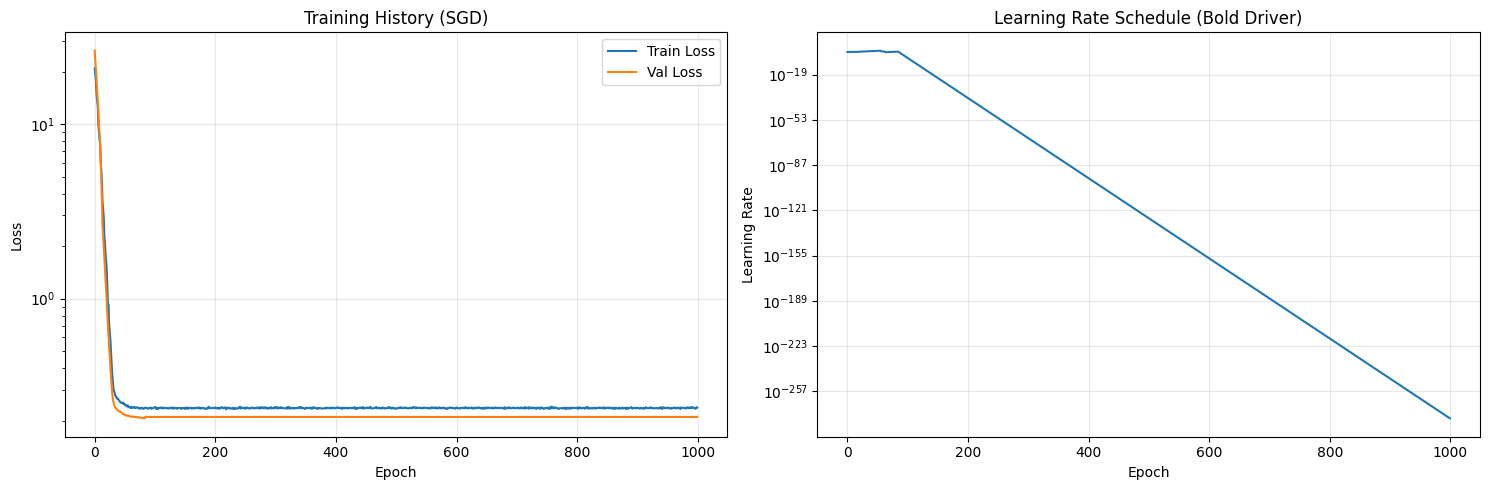

GPU Memory after training: 0.02 GB


In [ ]:
# ============================================================================
# Cell 8: Train the Network with SGD
# ============================================================================

# Clear GPU cache before training
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    print(f"GPU Memory before training: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

# Create network
depth = 5  # Network depth
model = MaterialNetwork(
    depth=depth,
    D1_init=X1_train[0],  # Reference compliance for phase 1
    D2_init=X2_train[0]   # Reference compliance for phase 2
).to(device)

print(f"Model depth: {depth}")
print(f"Bottom nodes: {model.n_bottom}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# Create trainer with SGD optimizer
# Key differences from Adam:
# 1. Higher learning rate (0.01 vs 0.001) - SGD needs larger steps
# 2. Optional momentum (0.9 can help convergence)
# 3. Bold driver adapts learning rate dynamically
trainer = Trainer(
    model,
    lr=0.01,          # Higher than Adam (0.001)
    lambda_reg=1e-6,  # Same regularization
    momentum=0.0      # Start with 0, can try 0.9 for faster convergence
)

# Train for more epochs since SGD converges slower than Adam
# Paper used 10000 epochs with SGD
trainer.train(
    train_loader,
    val_loader,
    epochs=1000,        # Increase if needed (paper used 10000)
    bold_driver=True,   # Enable Bold driver learning rate adaptation
    bold_driver_start_epoch=10  # Start adapting after 10 epochs
)

trainer.plot()

# GPU memory usage after training
if torch.cuda.is_available():
    print(f"GPU Memory after training: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

In [ ]:
# ============================================================================
# Cell 9: Test on Unseen Data
# ============================================================================

print("=" * 60)
print("TESTING ON UNSEEN DATA")
print("=" * 60)

model.eval()
test_losses = []

with torch.no_grad():
    for X1, X2, Y in test_loader:
        pred = model(X1, X2)
        for i in range(len(Y)):
            diff = pred[i] - Y[i]
            frob_error = torch.sum(diff**2)
            frob_target = torch.sum(Y[i]**2) + 1e-10
            loss = frob_error / frob_target
            test_losses.append(loss.item())

print(f"\nAverage Test Loss: {np.mean(test_losses):.6f} ({np.mean(test_losses)*100:.2f}%)")

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

with torch.no_grad():
    for i in range(min(5, len(test_dataset))):
        X1, X2, Y = test_dataset[i]
        pred = model(X1.unsqueeze(0), X2.unsqueeze(0)).squeeze(0)

        diff = pred - Y
        frob_error = torch.sum(diff**2)
        frob_target = torch.sum(Y**2) + 1e-10
        loss = frob_error / frob_target

        print(f"\nSample {i+1}:")
        print(f"  Target:    [{Y[0]:7.4f}, {Y[1]:7.4f}, {Y[2]:7.4f}, {Y[3]:7.4f}, {Y[4]:7.4f}, {Y[5]:7.4f}]")
        print(f"  Predicted: [{pred[0]:7.4f}, {pred[1]:7.4f}, {pred[2]:7.4f}, {pred[3]:7.4f}, {pred[4]:7.4f}, {pred[5]:7.4f}]")
        print(f"  Error: {loss.item():.6f} ({loss.item()*100:.2f}%)")

TESTING ON UNSEEN DATA

Average Test Loss: 0.226615 (22.66%)

SAMPLE PREDICTIONS

Sample 1:
  Target:    [ 2.3414, -0.0347, -0.0029,  0.2342,  0.0001,  0.9506]
  Predicted: [ 0.6642, -0.1537,  0.0547,  0.3014, -0.0583,  0.4895]
  Error: 0.473628 (47.36%)

Sample 2:
  Target:    [ 6.4611, -2.4754,  0.0950,  9.7385, -0.8662,  7.8388]
  Predicted: [ 6.7729, -3.2559,  0.2870,  6.2419,  0.1171,  4.5563]
  Error: 0.120592 (12.06%)

Sample 3:
  Target:    [ 5.8820, -0.6140, -0.0002,  0.6923,  0.0010,  2.2929]
  Predicted: [ 2.8641, -0.7732,  0.6602,  0.7296, -0.3465,  0.9036]
  Error: 0.285454 (28.55%)

Sample 4:
  Target:    [ 1.0074, -0.5695, -0.0007,  4.4084, -0.0002,  1.5590]
  Predicted: [ 1.1471, -0.4082,  0.0120,  2.9486,  0.0125,  0.9871]
  Error: 0.107911 (10.79%)

Sample 5:
  Target:    [ 0.2773, -0.0643,  0.0009,  0.5785, -0.0006,  0.5128]
  Predicted: [ 0.1229, -0.0100, -0.0967,  0.6000, -0.0195,  0.4200]
  Error: 0.067384 (6.74%)


In [ ]:
# ============================================================================
# Cell 11: Save Model
# ============================================================================

torch.save(model.state_dict(), 'dmn_pytorch.pt')
print("✓ Model saved to dmn_pytorch.pt")

from google.colab import files
files.download('dmn_pytorch.pt')
print("✓ Download initiated")

✓ Model saved to dmn_pytorch.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download initiated
